In [1]:
from pathlib import Path
import rasterio as rs
import numpy as np
import torch


clay_path = Path(r"D:\ml_datasets\Chukotka\Landsat_raw\pca\clay.tif")

tensor = torch.tensor(rs.open(clay_path).read(1)) 

In [2]:
q90 = np.nanquantile(tensor, 0.9)
tensor = tensor > q90

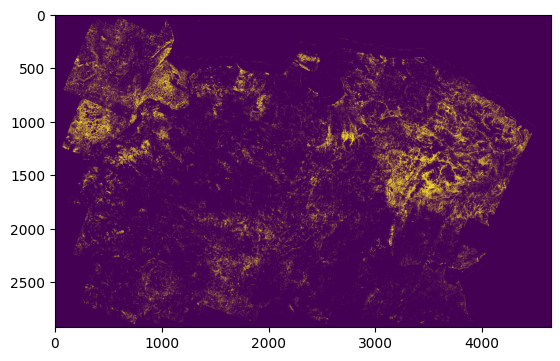

In [3]:
import matplotlib.pyplot as plt

plt.imshow(tensor[::10, ::10])

In [4]:
import torch
from utils.box_counting_v2 import make_multifractal_analysis

result = make_multifractal_analysis(
    torch.tensor(
        rs.open(clay_path).read(1)
    )
)

In [16]:
ds = rs.open(clay_path)
ds.meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': 0.0,
 'width': 46417,
 'height': 29228,
 'count': 7,
 'crs': CRS.from_wkt('PROJCS["unknown",GEOGCS["unknown",DATUM["unknown",SPHEROID["unknown",6378137,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Mercator_1SP"],PARAMETER["central_meridian",180],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'),
 'transform': Affine(76.4153952747502, 0.0, -3065306.9191963407,
        0.0, -76.41539527475027, 11336425.242236134)}

In [13]:
mask = ~np.isnan(rs.open(clay_path).read(1))

In [20]:
result.shape

(29228, 46417)

In [21]:
multifractal_dir = Path(r"D:\ml_datasets\Chukotka\Landsat_raw\multifractal")
multifractal_dir.mkdir(exist_ok=True)
with rs.open(multifractal_dir / "clay.tif", "w", **ds.meta) as dst:
    dst.write(np.where(mask, result, 0.0), 1)